In [1]:
pip install pandas openpyxl matplotlib numpy scipy

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.7 MB 11.9 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.7 MB 11.1 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.7 MB 9.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 8.7 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 8.0 MB/s  0:00:01
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 5.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 5.2 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 4.9 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 4.0 MB/s eta 0:00:01
   --------------------- --

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

In [2]:
#Folder where input data is stored
input_folder = "input_data"

#Folder where analysed results are stored
output_folder = "results"

print("Folders are set up!!")
print("Looking for files in:", os.path.abspath(input_folder))
print("Results will be stored in:", os.path.abspath(output_folder))

Folders are set up!!
Looking for files in: C:\Users\anith\Python script\Analysis\input_data
Results will be stored in: C:\Users\anith\Python script\Analysis\results


In [26]:
# Set high quality plot settings
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["xtick.major.width"] = 1.5
plt.rcParams["ytick.major.width"] = 1.5
plt.rcParams["lines.linewidth"] = 2.0

In [13]:
# Define subfolders
lsv_folder = os.path.join(input_folder, "LSV_data")
ca_folder = os.path.join(input_folder, "CA_data")

# Load LSV files
lsv_data = {}
for filename in os.listdir(lsv_folder):
    if filename.endswith(".xlsx"):
        label = filename.replace(".xlsx", "")
        filepath = os.path.join(lsv_folder, filename)
        lsv_data[label] = pd.read_excel(filepath)
        print(f"LSV loaded: {label} — {len(lsv_data[label])} rows")

print()

# Load CA files
ca_data = {}
for filename in os.listdir(ca_folder):
    if filename.endswith(".xlsx"):
        label = filename.replace(".xlsx", "")
        filepath = os.path.join(ca_folder, filename)
        ca_data[label] = pd.read_excel(filepath)
        print(f"CA loaded: {label} — {len(ca_data[label])} rows")

LSV loaded: 0 deg — 738 rows
LSV loaded: 180 deg — 738 rows
LSV loaded: 270 deg — 738 rows
LSV loaded: 90 deg — 738 rows
LSV loaded: LSV OER off after — 738 rows

CA loaded: CA at 0.7V - AC field — 25326 rows
CA loaded: CA at 0.7V - gradient field — 24257 rows


In [14]:
# Pick one file to explore (we'll use the first one found)
first_label = list(data.keys())[0]
df = data[first_label]

print("Label:", first_label)
print("Shape:", df.shape)  # rows and columns
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Label: 0 deg
Shape: (738, 7)

Column names:
['Potential applied (V)', 'Time (s)', 'WE(1).Current (A)', 'WE(1).Potential (V)', 'Index', 'Current range', 'Overload']

First 5 rows:


,Potential applied (V),Time (s),WE(1).Current (A),WE(1).Potential (V),Index,Current range,Overload
0,0.002441,6.639658,-0.000107,0.002502,1,100 µA,NaN
1,0.004883,7.127939,-0.000100,0.004935,2,100 µA,NaN
2,0.007324,7.616220,-0.000094,0.007388,3,100 µA,NaN
3,0.009766,8.104501,-0.000089,0.009814,4,100 µA,NaN
4,0.012207,8.592782,-0.000084,0.012268,5,100 µA,NaN


In [15]:
# Electrode area in cm²
electrode_area = 0.25  # 5mm x 5mm

# Reference electrode conversion to RHE
# E(RHE) = E(Hg/HgO) + 0.098 + (0.059 x pH)
pH = 14
ref_conversion = 0.098 + (0.059 * pH)

print(f"Electrode area: {electrode_area} cm²")
print(f"Reference electrode conversion to RHE: {ref_conversion:.3f} V")

Electrode area: 0.25 cm²
Reference electrode conversion to RHE: 0.924 V


In [23]:
# Clean all loaded dataframes
clean_lsv = {}

for label, df in lsv_data.items():
    # Make a copy so we don't modify the original
    df_clean = df.copy()
    
    # Drop rows with any missing values
    df_clean = df_clean.dropna(subset=["Potential applied (V)", "WE(1).Current (A)"])
    
    # Convert potential to RHE
    df_clean["E vs RHE (V)"] = df_clean["Potential applied (V)"] + ref_conversion
    
    # Convert current (A) to current density (mA/cm²)
    df_clean["Current density (mA/cm2)"] = (df_clean["WE(1).Current (A)"] * 1000) / electrode_area
    
    # Store cleaned data
    clean_lsv[label] = df_clean
    
    print(f"{label}:")
    print(f"  Rows after cleaning: {len(df_clean)}")
    print(f"  Potential range (RHE): {df_clean['E vs RHE (V)'].min():.3f} to {df_clean['E vs RHE (V)'].max():.3f} V")
    print(f"  Current density range: {df_clean['Current density (mA/cm2)'].min():.3f} to {df_clean['Current density (mA/cm2)'].max():.3f} mA/cm²")
    print()

0 deg:
  Rows after cleaning: 738
  Potential range (RHE): 0.926 to 2.726 V
  Current density range: -0.428 to 40.000 mA/cm²

180 deg:
  Rows after cleaning: 738
  Potential range (RHE): 0.926 to 2.726 V
  Current density range: -0.571 to 40.000 mA/cm²

270 deg:
  Rows after cleaning: 738
  Potential range (RHE): 0.926 to 2.726 V
  Current density range: -0.580 to 40.000 mA/cm²

90 deg:
  Rows after cleaning: 738
  Potential range (RHE): 0.926 to 2.726 V
  Current density range: -0.502 to 40.000 mA/cm²

LSV OER off after:
  Rows after cleaning: 738
  Potential range (RHE): 0.926 to 2.726 V
  Current density range: -0.505 to 40.000 mA/cm²



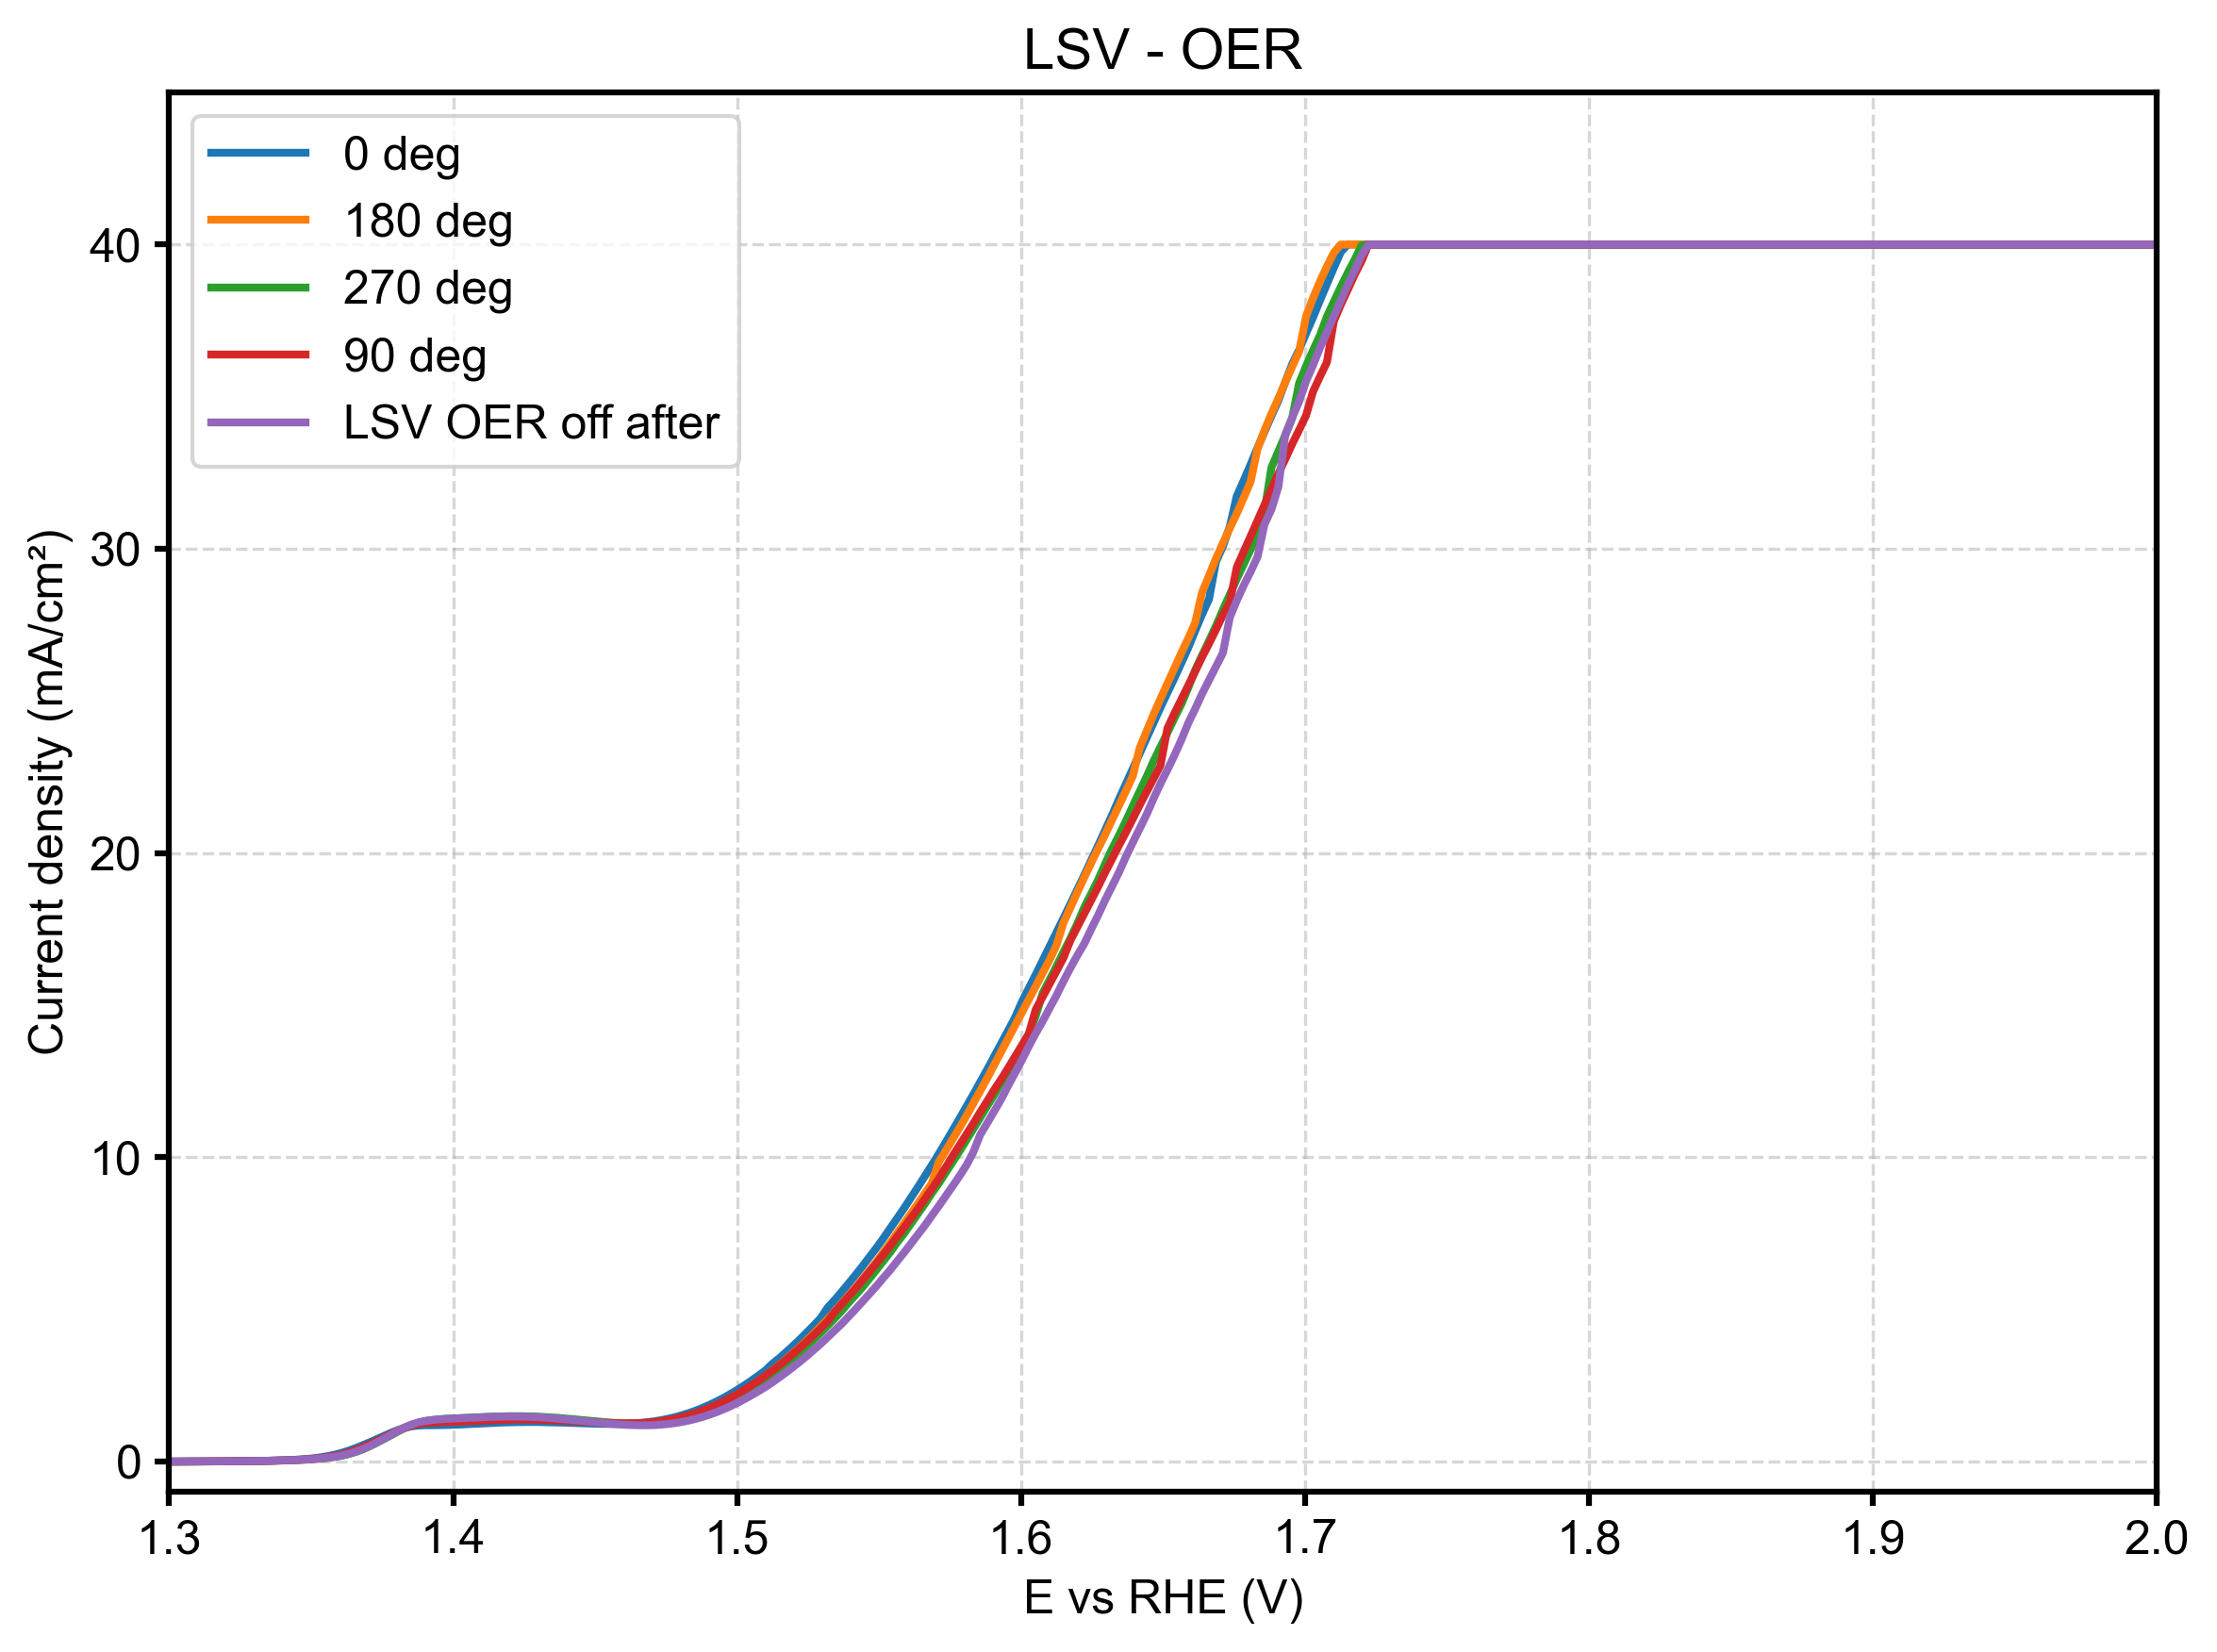

In [28]:
#Plotting LSV_plots
plt.figure(figsize=(8, 6))

for label, df in clean_lsv.items():
    plt.plot(df["E vs RHE (V)"], df["Current density (mA/cm2)"], label=label)

# Axis labels
plt.xlabel("E vs RHE (V)")
plt.ylabel("Current density (mA/cm²)")
plt.title("LSV - OER")

# Axis limits
plt.xlim(1.3, 2.0)
plt.ylim(-1, 45)

# Add legend and grid
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [29]:
# Tafel analysis
tafel_results = {}

for label, df in clean_lsv.items():
    # Find index where current density first reaches 10 mA/cm²
    idx_10 = df[df["Current density (mA/cm2)"] >= 10].index[0]
    
    # Take 10 points from that index onwards
    tafel_df = df.loc[idx_10 : idx_10 + 9].copy()
    
    # Calculate overpotential (V vs RHE - 1.23)
    tafel_df["Overpotential (V)"] = tafel_df["E vs RHE (V)"] - 1.23
    
    # Calculate log(j)
    tafel_df["log(j)"] = np.log10(tafel_df["Current density (mA/cm2)"])
    
    # Fit a line through overpotential vs log(j)
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        tafel_df["log(j)"], tafel_df["Overpotential (V)"]
    )
    
    # Convert slope to mV/dec
    tafel_slope_mv = slope * 1000
    
    # Onset potential and overpotential at 10 mA/cm²
    onset_potential = tafel_df["E vs RHE (V)"].iloc[0]
    overpotential_mv = (onset_potential - 1.23) * 1000
    
    # Store results
    tafel_results[label] = {
        "Onset potential (V)": round(onset_potential, 4),
        "Overpotential (mV)": round(overpotential_mv, 2),
        "Tafel slope (mV/dec)": round(tafel_slope_mv, 1),
        "R²": round(r_value**2, 4),
        "tafel_df": tafel_df,
        "slope": slope,
        "intercept": intercept
    }
    
    print(f"{label}: Onset = {onset_potential:.4f} V | Overpotential = {overpotential_mv:.2f} mV | Tafel slope = {tafel_slope_mv:.1f} mV/dec | R² = {r_value**2:.4f}")
    

0 deg: Onset = 1.5710 V | Overpotential = 340.97 mV | Tafel slope = 165.2 mV/dec | R² = 0.9993
180 deg: Onset = 1.5734 V | Overpotential = 343.41 mV | Tafel slope = 163.4 mV/dec | R² = 0.9996
270 deg: Onset = 1.5783 V | Overpotential = 348.30 mV | Tafel slope = 174.7 mV/dec | R² = 0.9993
90 deg: Onset = 1.5759 V | Overpotential = 345.86 mV | Tafel slope = 179.5 mV/dec | R² = 0.9985
LSV OER off after: Onset = 1.5832 V | Overpotential = 353.18 mV | Tafel slope = 159.4 mV/dec | R² = 0.9968


In [30]:
import pandas as pd

# Build results table
table = []
for label, results in tafel_results.items():
    table.append({
        "Condition": label,
        "Onset potential (V)": results["Onset potential (V)"],
        "Overpotential (mV)": results["Overpotential (mV)"],
        "Tafel slope (mV/dec)": results["Tafel slope (mV/dec)"],
        "R²": results["R²"]
    })

results_df = pd.DataFrame(table)
results_df = results_df.set_index("Condition")
print(results_df)

                   Onset potential (V)  Overpotential (mV)  \
Condition                                                    
0 deg                           1.5710              340.97   
180 deg                         1.5734              343.41   
270 deg                         1.5783              348.30   
90 deg                          1.5759              345.86   
LSV OER off after               1.5832              353.18   

                   Tafel slope (mV/dec)      R²  
Condition                                        
0 deg                             165.2  0.9993  
180 deg                           163.4  0.9996  
270 deg                           174.7  0.9993  
90 deg                            179.5  0.9985  
LSV OER off after                 159.4  0.9968  


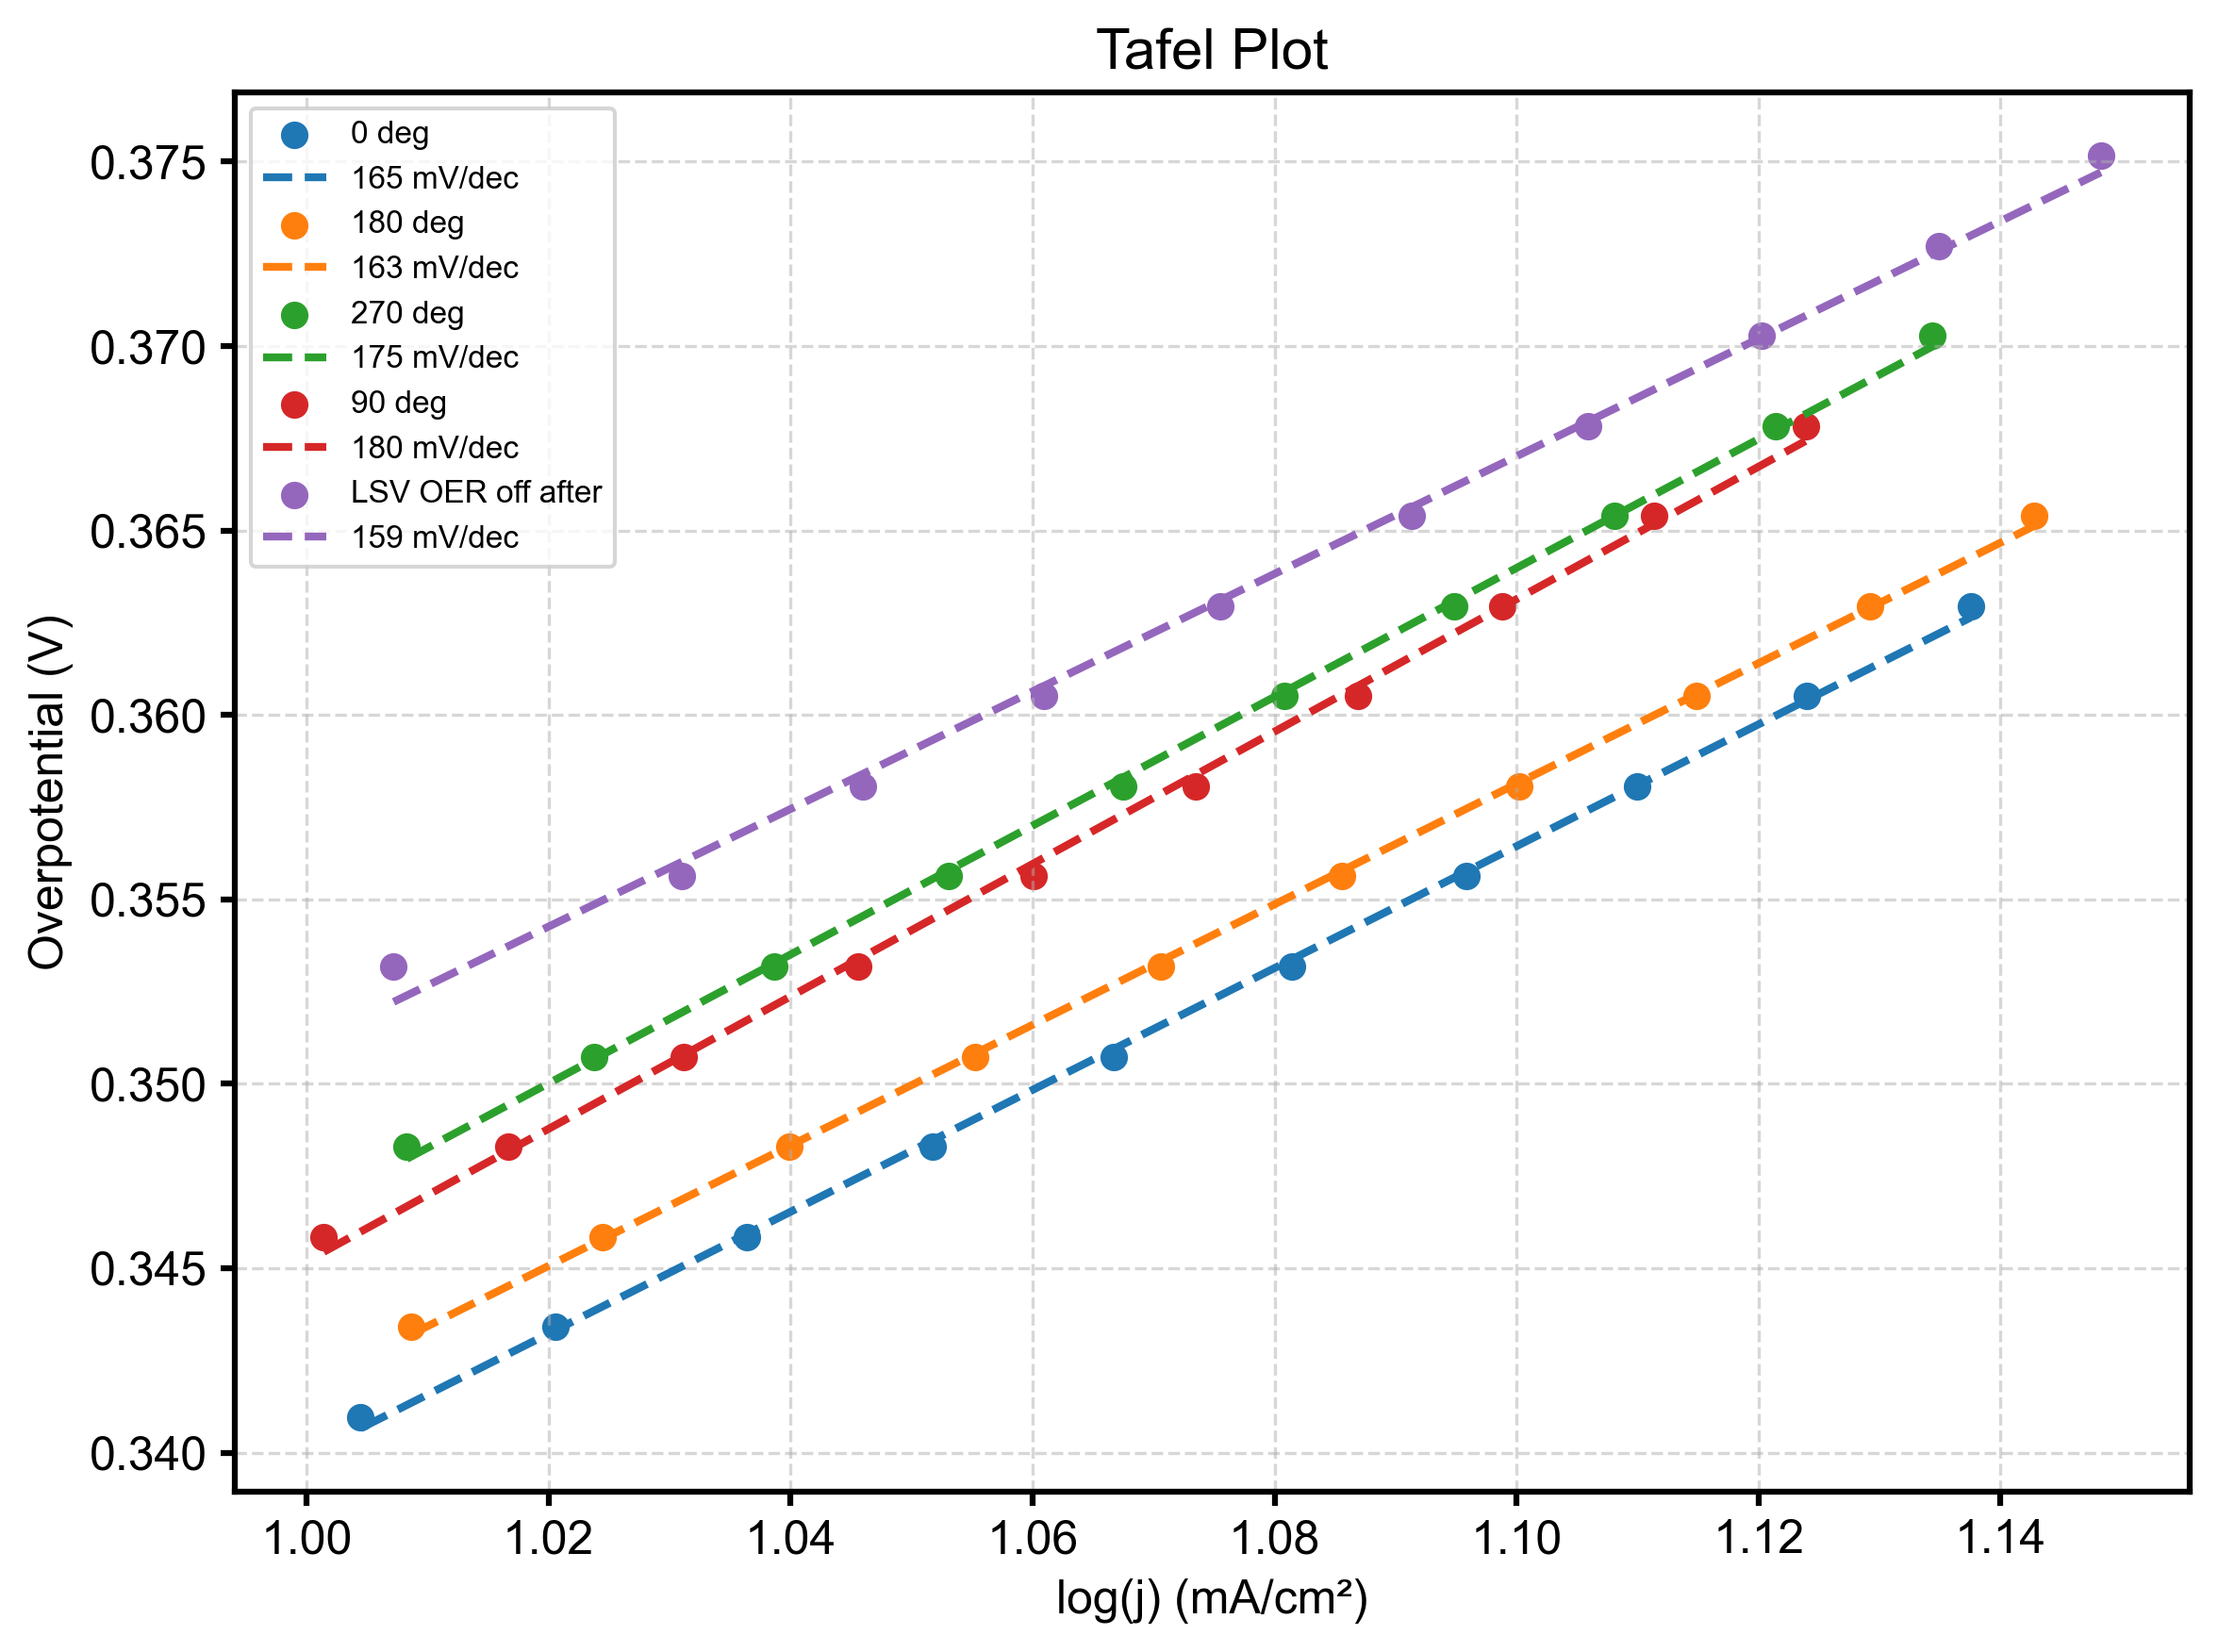

In [31]:
plt.figure(figsize=(8, 6))

for label, results in tafel_results.items():
    tafel_df = results["tafel_df"]
    slope = results["slope"]
    intercept = results["intercept"]
    tafel_slope_mv = results["Tafel slope (mV/dec)"]
    
    # Plot the data points
    plt.scatter(tafel_df["log(j)"], tafel_df["Overpotential (V)"], label=label)
    
    # Plot the fitted line
    x_fit = np.linspace(tafel_df["log(j)"].min(), tafel_df["log(j)"].max(), 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, linestyle="--", label=f"{tafel_slope_mv:.0f} mV/dec")

# Axis labels
plt.xlabel("log(j) (mA/cm²)")
plt.ylabel("Overpotential (V)")
plt.title("Tafel Plot")

# Legend and grid
plt.legend(fontsize=8)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
#CA analysis
for label, df in ca_data.items():
    print(f"{label}:")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Rows: {len(df)}")
    print(f"  Time range: {df['Time (s)'].min():.2f} to {df['Time (s)'].max():.2f} s")
    print(f"  Current range: {df['WE(1).Current (A)'].min():.6f} to {df['WE(1).Current (A)'].max():.6f} A")
    print()

CA at 0.7V - AC field:
  Columns: ['Time (s)', 'WE(1).Potential (V)', 'WE(1).Current (A)', 'Corrected time (s)', 'Index']
  Rows: 25326
  Time range: 0.50 to 253.75 s
  Current range: 0.004717 to 0.010000 A

CA at 0.7V - gradient field:
  Columns: ['Time (s)', 'WE(1).Potential (V)', 'WE(1).Current (A)', 'Corrected time (s)', 'Index']
  Rows: 24257
  Time range: 0.41 to 242.97 s
  Current range: 0.004888 to 0.010000 A



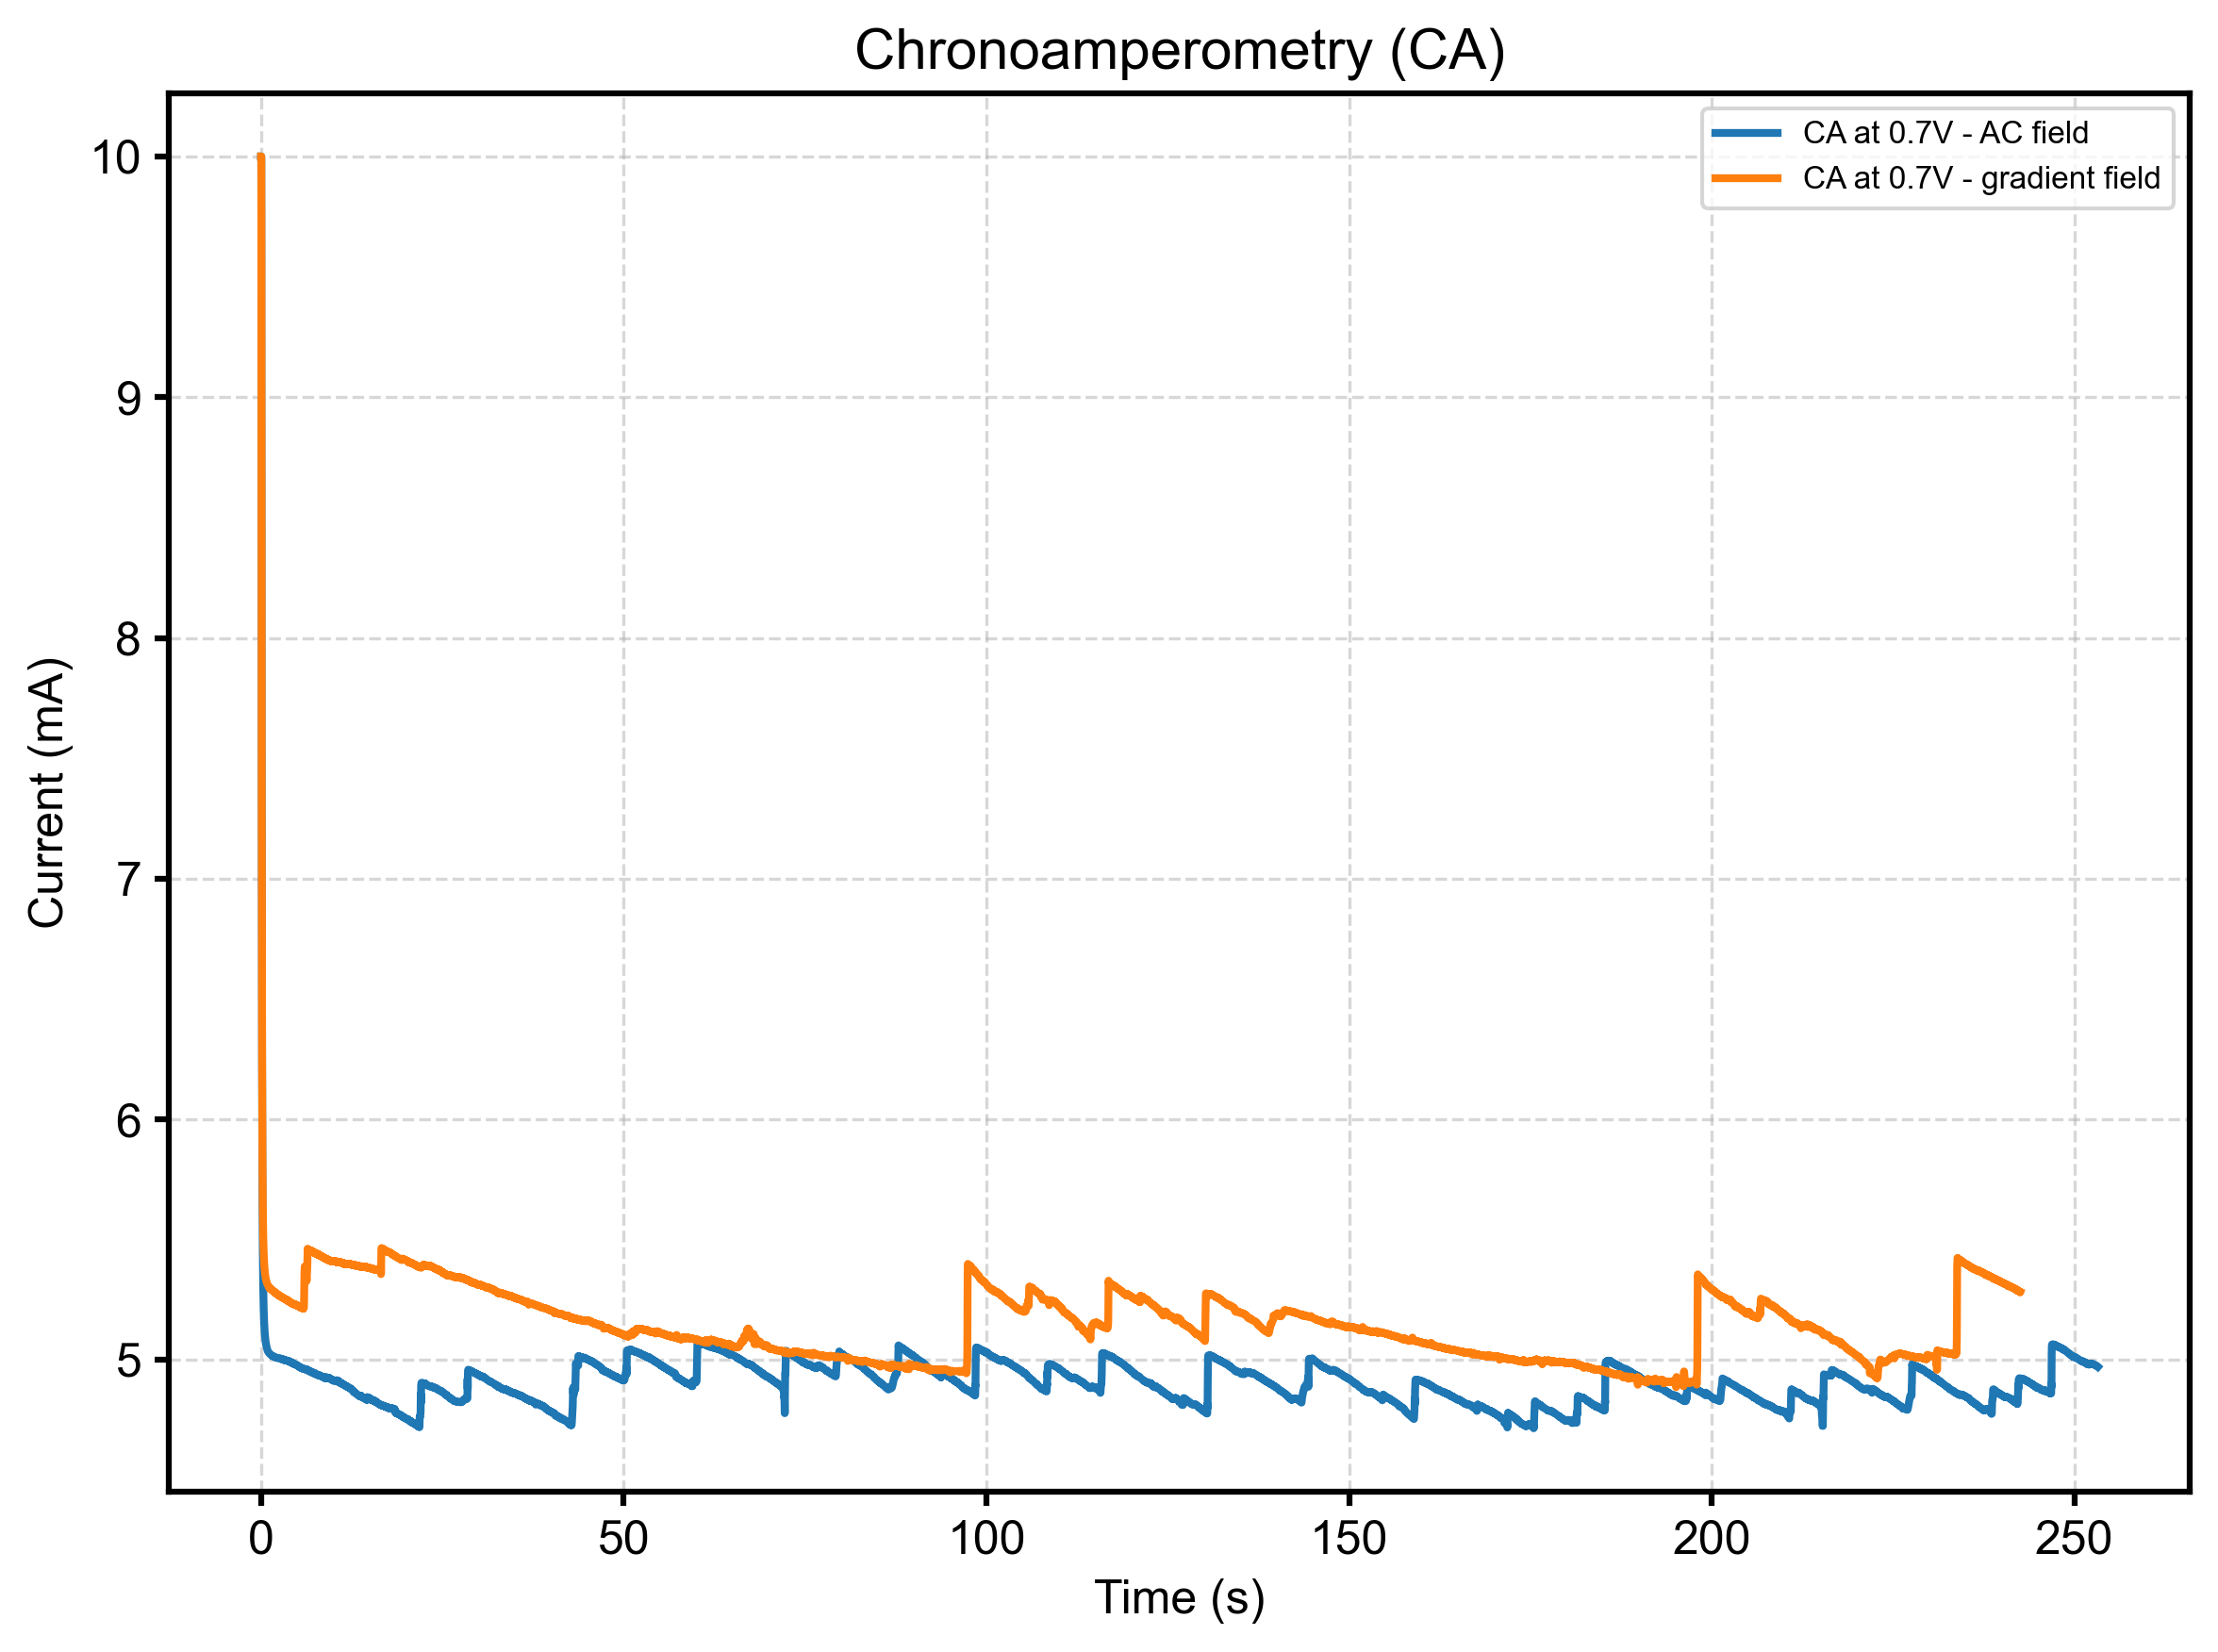

In [33]:
#Plot CA_figures
plt.figure(figsize=(8, 6))

for label, df in ca_data.items():
    # Convert current from A to mA
    current_ma = df["WE(1).Current (A)"] * 1000
    
    # Use corrected time if available, otherwise use time
    if "Corrected time (s)" in df.columns:
        time = df["Corrected time (s)"]
    else:
        time = df["Time (s)"]
    
    plt.plot(time, current_ma, label=label)

# Axis labels
plt.xlabel("Time (s)")
plt.ylabel("Current (mA)")
plt.title("Chronoamperometry (CA)")

# Legend and grid
plt.legend(fontsize=8)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\anith\AppData\Local\Temp\ipykernel_16592\4144348937.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Report saved as PNG and PDF in results folder!


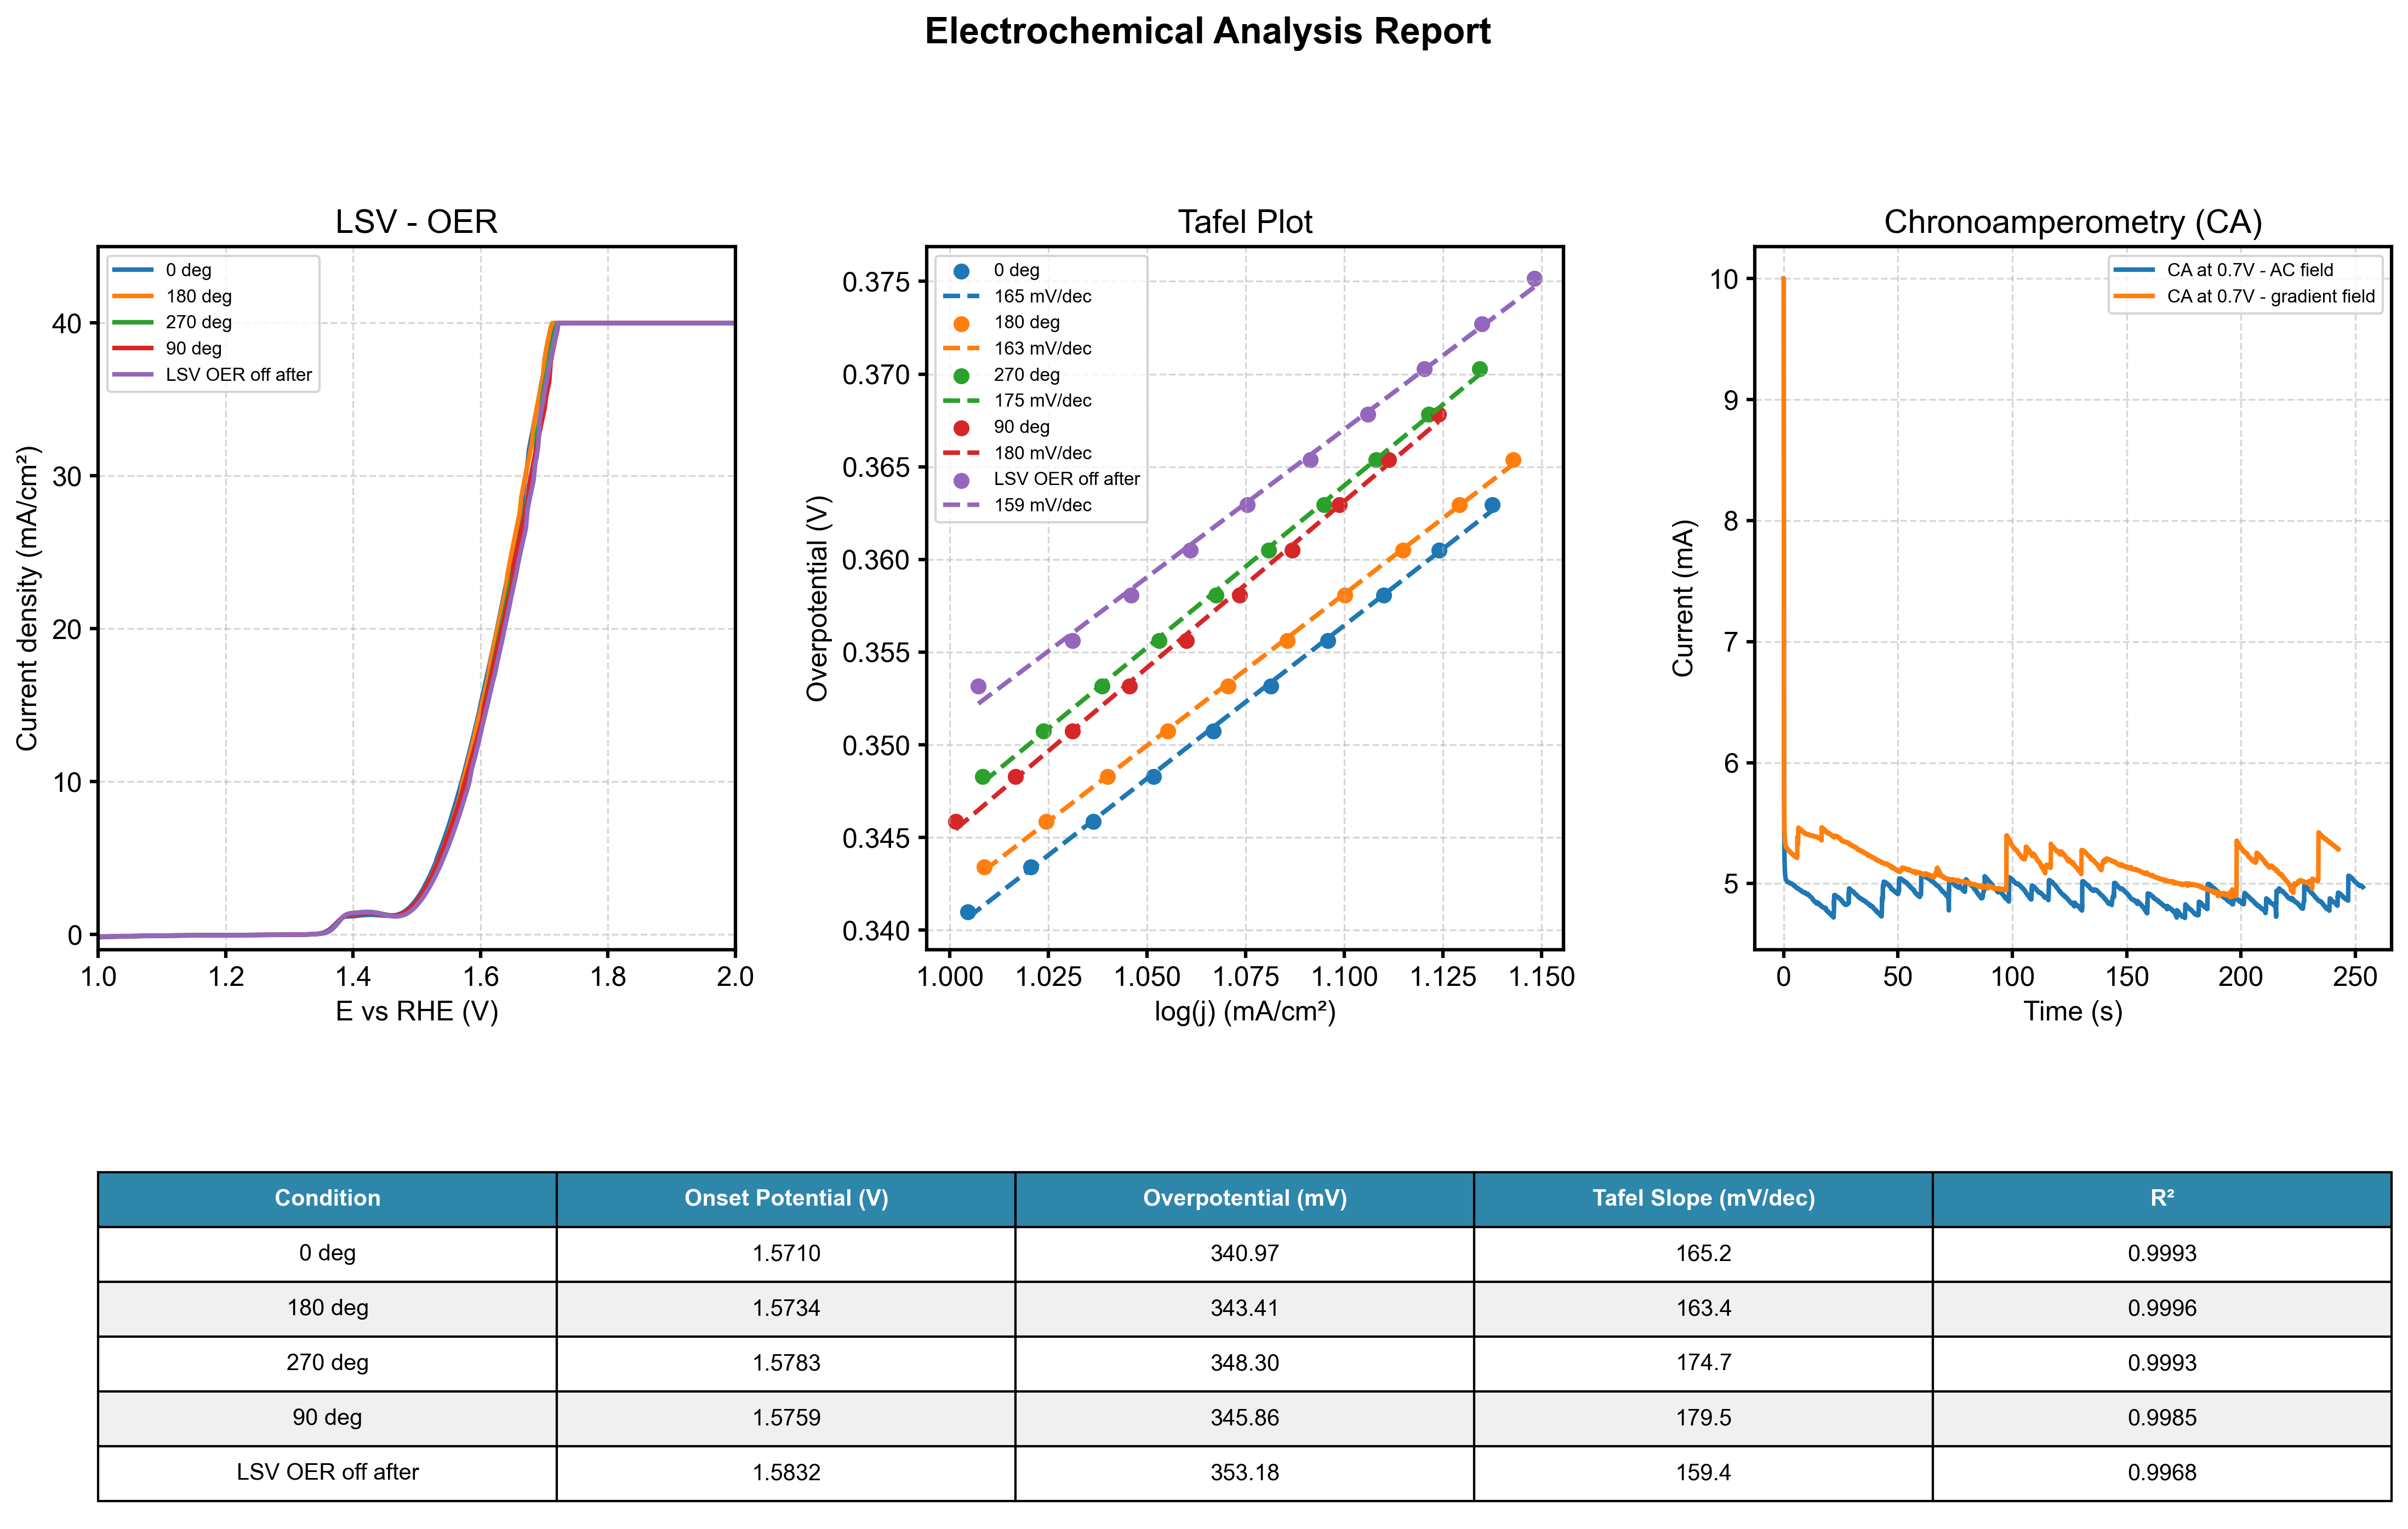

In [36]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec

# Create figure
fig = plt.figure(figsize=(18, 10))

# Create grid - 2 rows, 3 columns
# Top row for plots, bottom row for table
gs = gridspec.GridSpec(2, 3, height_ratios=[2, 1], hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])  # LSV
ax2 = fig.add_subplot(gs[0, 1])  # Tafel
ax3 = fig.add_subplot(gs[0, 2])  # CA
ax4 = fig.add_subplot(gs[1, :])  # Table spans full bottom row

# ---- Panel 1: LSV ----
for label, df in clean_lsv.items():
    ax1.plot(df["E vs RHE (V)"], df["Current density (mA/cm2)"], label=label)

ax1.set_xlabel("E vs RHE (V)")
ax1.set_ylabel("Current density (mA/cm²)")
ax1.set_title("LSV - OER")
ax1.set_xlim(1.0, 2.0)
ax1.set_ylim(-1, 45)
ax1.legend(fontsize=8)
ax1.grid(True, linestyle="--", alpha=0.5)

# ---- Panel 2: Tafel ----
for label, results in tafel_results.items():
    tafel_df = results["tafel_df"]
    slope = results["slope"]
    intercept = results["intercept"]
    tafel_slope_mv = results["Tafel slope (mV/dec)"]
    
    ax2.scatter(tafel_df["log(j)"], tafel_df["Overpotential (V)"], label=label)
    x_fit = np.linspace(tafel_df["log(j)"].min(), tafel_df["log(j)"].max(), 100)
    y_fit = slope * x_fit + intercept
    ax2.plot(x_fit, y_fit, linestyle="--", label=f"{tafel_slope_mv:.0f} mV/dec")

ax2.set_xlabel("log(j) (mA/cm²)")
ax2.set_ylabel("Overpotential (V)")
ax2.set_title("Tafel Plot")
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.5)

# ---- Panel 3: CA ----
for label, df in ca_data.items():
    current_ma = df["WE(1).Current (A)"] * 1000
    if "Corrected time (s)" in df.columns:
        time = df["Corrected time (s)"]
    else:
        time = df["Time (s)"]
    ax3.plot(time, current_ma, label=label)

ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Current (mA)")
ax3.set_title("Chronoamperometry (CA)")
ax3.legend(fontsize=8)
ax3.grid(True, linestyle="--", alpha=0.5)

# ---- Panel 4: Tafel Results Table ----
ax4.axis("off")  # hide axes for table panel

# Build table data
col_labels = ["Condition", "Onset Potential (V)", "Overpotential (mV)", "Tafel Slope (mV/dec)", "R²"]
table_data = []
for label, results in tafel_results.items():
    table_data.append([
        label,
        f"{results['Onset potential (V)']:.4f}",
        f"{results['Overpotential (mV)']:.2f}",
        f"{results['Tafel slope (mV/dec)']:.1f}",
        f"{results['R²']:.4f}"
    ])

# Draw table
table = ax4.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)  # make rows taller

# Style header row
for col in range(len(col_labels)):
    table[0, col].set_facecolor("#2E86AB")
    table[0, col].set_text_props(color="white", fontweight="bold")

# Style data rows alternating colors
for row in range(1, len(table_data) + 1):
    for col in range(len(col_labels)):
        if row % 2 == 0:
            table[row, col].set_facecolor("#F0F0F0")
        else:
            table[row, col].set_facecolor("white")

# Add main title
fig.suptitle("Electrochemical Analysis Report", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()

# Save as PNG
plt.savefig(os.path.join(output_folder, "report.png"), dpi=300, bbox_inches="tight")

# Save as PDF
with PdfPages(os.path.join(output_folder, "report.pdf")) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print("Report saved as PNG and PDF in results folder!")
plt.show()